# Linear Algebra Fundamentals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/00-foundations/math-for-ml/01_linear_algebra.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Vectors: operations, dot product, norms
- Matrices: multiplication, transpose, inverse
- Eigenvalues & Eigenvectors
- Determinants & Rank
- Why this matters in ML

## Why Linear Algebra?

All ML models are matrices. Understanding linear algebra means understanding how data transforms through neural networks, dimensionality reduction, and feature spaces.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(f"NumPy: {np.__version__}")

NumPy: 2.0.2


---
## 1. Vectors

In [16]:
# Vectors are 1D arrays
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])

print(f"v1: {v1}")
print(f"v2: {v2}")
print(f"Shape: {v1.shape}")

v1: [1 2 3]
v2: [4 5 6]
Shape: (3,)


In [17]:
# Vector addition
print("Vector Addition:")
print(f"v1 + v2 = {v1 + v2}")

# Scalar multiplication
print("\nScalar Multiplication:")
print(f"2 * v1 = {2 * v1}")

# Dot product (crucial!)
print("\nDot Product:")
dot_product = np.dot(v1, v2)
print(f"v1 · v2 = {dot_product}")
print(f"Calculation: 1*4 + 2*5 + 3*6 = {1*4 + 2*5 + 3*6}")

Vector Addition:
v1 + v2 = [5 7 9]

Scalar Multiplication:
2 * v1 = [2 4 6]

Dot Product:
v1 · v2 = 32
Calculation: 1*4 + 2*5 + 3*6 = 32


In [18]:
# Vector norms (lengths)
print("Vector Norms:")

# L2 norm (Euclidean distance)
l2_norm = np.linalg.norm(v1)
print(f"L2 norm of v1: {l2_norm}")
print(f"sqrt(1² + 2² + 3²) = {np.sqrt(1**2 + 2**2 + 3**2)}")

# L1 norm (Manhattan distance)
l1_norm = np.linalg.norm(v1, ord=1)
print(f"\nL1 norm of v1: {l1_norm}")
print(f"|1| + |2| + |3| = {abs(1) + abs(2) + abs(3)}")

Vector Norms:
L2 norm of v1: 3.7416573867739413
sqrt(1² + 2² + 3²) = 3.7416573867739413

L1 norm of v1: 6.0
|1| + |2| + |3| = 6


---
## 2. Matrices

In [19]:
# Matrices are 2D arrays
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

B = np.array([
    [7, 8],
    [9, 10],
    [11, 12]
])

print(f"Matrix A shape: {A.shape}")
print(f"Matrix B shape: {B.shape}")
print(f"\nA = \n{A}")

Matrix A shape: (2, 3)
Matrix B shape: (3, 2)

A = 
[[1 2 3]
 [4 5 6]]


In [20]:
# Matrix multiplication (this is what happens in neural networks!)
print("Matrix Multiplication:")
C = np.matmul(A, B)  # or A @ B
print(f"A @ B = \n{C}")
print(f"Shape: {C.shape}")

Matrix Multiplication:
A @ B = 
[[ 58  64]
 [139 154]]
Shape: (2, 2)


In [21]:
# Transpose
print("Transpose:")
print(f"A.T = \n{A.T}")

# Inverse (for square matrices)
A_square = np.array([
    [1, 2],
    [3, 4]
])

A_inv = np.linalg.inv(A_square)
print(f"\nA_square = \n{A_square}")
print(f"\nA_square^-1 = \n{A_inv}")

# Verify: A @ A^-1 = I
print(f"\nA @ A^-1 = \n{np.matmul(A_square, A_inv)}")

Transpose:
A.T = 
[[1 4]
 [2 5]
 [3 6]]

A_square = 
[[1 2]
 [3 4]]

A_square^-1 = 
[[-2.   1. ]
 [ 1.5 -0.5]]

A @ A^-1 = 
[[1.0000000e+00 0.0000000e+00]
 [8.8817842e-16 1.0000000e+00]]


---
## 3. Determinant & Rank

In [22]:
# Determinant (tells you about invertibility)
det = np.linalg.det(A_square)
print(f"Determinant of A_square: {det}")
print(f"Manual calculation: (1*4) - (2*3) = {1*4 - 2*3}")

# If det = 0, matrix is singular (not invertible)
singular_matrix = np.array([
    [1, 2],
    [2, 4]
])
det_singular = np.linalg.det(singular_matrix)
print(f"\nDeterminant of singular matrix: {det_singular}")

Determinant of A_square: -2.0000000000000004
Manual calculation: (1*4) - (2*3) = -2

Determinant of singular matrix: 0.0


In [23]:
# Rank (number of independent rows/columns)
rank_A = np.linalg.matrix_rank(A)
rank_singular = np.linalg.matrix_rank(singular_matrix)

print(f"Rank of A (2x3 matrix): {rank_A}")
print(f"Rank of singular matrix: {rank_singular}")
print(f"\nRank tells us how much 'information' the matrix has")

Rank of A (2x3 matrix): 2
Rank of singular matrix: 1

Rank tells us how much 'information' the matrix has


---
## 4. Eigenvalues & Eigenvectors

In [24]:
# Eigenvalues and eigenvectors
# For square matrix A: A @ v = λ * v
# v = eigenvector, λ = eigenvalue

A_sym = np.array([
    [4, 1],
    [1, 3]
])

eigenvalues, eigenvectors = np.linalg.eig(A_sym)

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")

Eigenvalues: [4.61803399 2.38196601]
Eigenvectors:
[[ 0.85065081 -0.52573111]
 [ 0.52573111  0.85065081]]


In [25]:
# Verify: A @ v = λ * v
v = eigenvectors[:, 0]  # First eigenvector
lam = eigenvalues[0]    # First eigenvalue

left_side = np.matmul(A_sym, v)
right_side = lam * v

print(f"A @ v = {left_side}")
print(f"λ * v = {right_side}")
print(f"Equal? {np.allclose(left_side, right_side)}")

A @ v = [3.92833435 2.42784414]
λ * v = [3.92833435 2.42784414]
Equal? True


---
## 5. Practical: Principal Component Analysis Intuition

In [26]:
# Create 2D data
np.random.seed(42)
data = np.random.randn(100, 2) @ np.array([[3, 1], [1, 1]])  # Correlated data

# Compute covariance matrix
cov_matrix = np.cov(data.T)
print(f"Covariance matrix:\n{cov_matrix}")

# Get eigenvalues/eigenvectors (principal components!)
evals, evecs = np.linalg.eig(cov_matrix)

print(f"\nEigenvalues (variances): {evals}")
print(f"Eigenvectors (directions):\n{evecs}")

Covariance matrix:
[[7.76304649 3.30812019]
 [3.30812019 1.78628315]]

Eigenvalues (variances): [9.23270073 0.3166289 ]
Eigenvectors (directions):
[[ 0.91387525 -0.40599511]
 [ 0.40599511  0.91387525]]


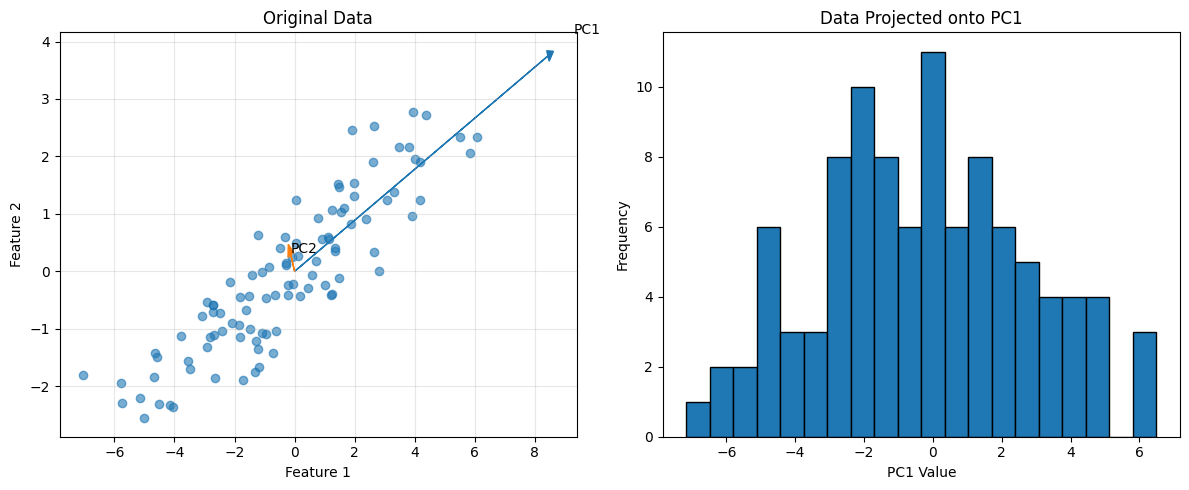

Variance explained by PC1: 96.7%


In [27]:
# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original data
ax1.scatter(data[:, 0], data[:, 1], alpha=0.6)
ax1.set_title('Original Data')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)

# Add principal components as arrows
for i, (eval, evec) in enumerate(zip(evals, evecs.T)):
    ax1.arrow(0, 0, evec[0]*eval, evec[1]*eval, head_width=0.2, head_length=0.2, fc=f'C{i}', ec=f'C{i}')
    ax1.text(evec[0]*eval*1.1, evec[1]*eval*1.1, f'PC{i+1}', fontsize=10)

# Data projected onto PC1
pc1 = evecs[:, 0]
data_projected = np.dot(data, pc1)
ax2.hist(data_projected, bins=20, edgecolor='black')
ax2.set_title('Data Projected onto PC1')
ax2.set_xlabel('PC1 Value')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {evals[0]/evals.sum()*100:.1f}%")

---
## 6. Key Formulas (Cheat Sheet)

| Operation | Formula | Python |
|-----------|---------|--------|
| Dot Product | v·w = Σvᵢwᵢ | `np.dot(v, w)` |
| Matrix Mult | (A×B)ᵢⱼ = ΣAᵢₖBₖⱼ | `A @ B` |
| L2 Norm | \|v\| = √(Σvᵢ²) | `np.linalg.norm(v)` |
| Transpose | Aᵀ | `A.T` |
| Inverse | A⁻¹ | `np.linalg.inv(A)` |
| Determinant | det(A) | `np.linalg.det(A)` |
| Eigenvalues | A·v = λ·v | `np.linalg.eig(A)` |
| Rank | Independent rows | `np.linalg.matrix_rank(A)` |

---
## Your Turn

1. Create two random 3×3 matrices and compute their product
2. Verify that det(A) = 0 for a singular matrix
3. Find eigenvalues of a 2×2 covariance matrix from random data

In [28]:
# Your code here